# Analysis over data preparation for datasets with `GenMET_pt` as target

After cleaning each dataset from undesired events and adding new engineered features, we mimik the analyses done in the data understanding phase.

Below are defined the functions later called for each dataset:
- `_load_dataset(*)` loads the `.root` files and returns a Pandas DataFrame;
- `_correlation_heatmap(*)` shows the Pearson and Spearman correlation heatmap between continuous features only;
- `_scatterplot_MET(*)` shows the relationship between the features `MET_pt` and `GenMET_pt`;
- `_data_distributions(*)` shows the distributions via histograms of the continuous features;
- `_boxplots(*)` shows the boxplot for each continuous feature to indentify outliers;
- `_data_barplots(*)` shows the barplots for each descrete feature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

/home/matilde/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
DATASETS = {
    "DYJetsToLL":   "../../TestingDatasets/testing_DYJetsToLL.root",
    "HToAATo2Mu2B": "../../TestingDatasets/testing_HToAATo2Mu2B.root",
    "ZZTo2L2Nu":    "../../TestingDatasets/testing_ZZTo2L2Nu.root",
}

TREE_NAME = "Events"

PALETTE = ["royalblue", "orangered", "darkgreen"]

In [3]:
def _load_dataset(path, tree_name):
    with uproot.open(f"{path}:{tree_name}") as tree:
        scalar_branches = []
        for name in tree.keys():
            try:
                interp = tree[name].interpretation
                dtype = interp.numpy_dtype
                if dtype.shape == ():
                    scalar_branches.append(name)
            except Exception:
                pass

        df = tree.arrays(scalar_branches, library="pd")

    float_features = df.select_dtypes(include=["float32", "float64"]).columns.tolist()
    int_features   = df.select_dtypes(include=["int32", "int64", "uint32", "uint64"]).columns.tolist()

    df[float_features] = df[float_features].astype(np.float64)
    df[int_features]   = df[int_features].astype(np.int64)

    print(f"Auto-detected {len(float_features)} float features, {len(int_features)} int features")
    return df, float_features, int_features

In [4]:
def _correlation_heatmap(df, label, float_features, method="pearson"):
    corr = (
        df[float_features]
        .replace([np.inf, -np.inf], np.nan)
        .corr(method=method)
    )

    print(f"\nCouples of features with {method} correlation > 0.70:")
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i):
            corr_value = corr.iloc[i, j]
            if abs(corr_value) > 0.70:
                feat1 = corr.columns[i]
                feat2 = corr.columns[j]
                high_corr.append((feat1, feat2, corr_value))
                print(f"{feat1}, {feat2} = {corr_value:.2f}")

    if "GenMET_pt" in corr.columns:
        print(f"\n{method.capitalize()} correlation with GenMET_pt:")
        genmet_corr = (
            corr["GenMET_pt"]
            .drop("GenMET_pt")
            .sort_values(key=abs, ascending=False)
        )
        for feat, val in genmet_corr.items():
            print(f"    {feat:<35} {val:+.3f}")
            
    # Mapping features
    feature_map = {
        col: f"F{i+1}"
        for i, col in enumerate(corr.columns)
    }

    corr_plot = corr.rename(
        index=feature_map,
        columns=feature_map
    )

    fig, ax = plt.subplots(figsize=(16, 12))

    sns.heatmap(
        corr_plot,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor="gray",
        annot_kws={"size": 7},
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )

    ax.set_title(
        f"{method.capitalize()} correlation heatmap - {label}",
        fontsize=14,
        pad=15,
    )

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=9,
    )

    # Legend
    legend_text = "\n".join(
        f"{feature_map[col]:<4} : {col}"
        for col in corr.columns
    )

    fig.text(
        1.02,
        0.5,
        legend_text,
        fontsize=8,
        va="center",
        family="monospace",
    )

    plt.tight_layout()
    plt.show()
    return

In [5]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"  MET_pt:\n{x.describe()}\n")
    print(f"  GenMET_pt:\n{y.describe()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [6]:
def _data_distributions(df, float_features, label, color):
    n_feat = len(float_features)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(float_features):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=100, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [7]:
def _boxplots(df, float_features, label, color):
    n_feat = len(float_features)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers - {label}")

    for idx, feat in enumerate(float_features):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [8]:
def _data_barplots(df, label, color):
    solo_features = ["nSV", "PV_npvs", "PV_npvsGood"]
    n_plots = len(solo_features) + 1
    ncols = 2
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    def draw_bar(ax, feat):
        vals = df[feat].dropna()
        bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
        centers = (bins[:-1] + bins[1:]) / 2
        counts, _ = np.histogram(vals, bins=bins)
        ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)

    for idx, feat in enumerate(solo_features):
        ax = axes[idx]
        draw_bar(ax, feat)
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel("Counts", fontsize=10)
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    for j in range(len(solo_features), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

---

## DYJetsToLL dataset

In [9]:
label = list(DATASETS.items())[0][0]
path = DATASETS.get("DYJetsToLL")
color = PALETTE[0]

df, float_features, int_features = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Auto-detected 44 float features, 4 int features
Dataset DYJetsToLL:
    48 features x 571928 events



Couples of features with pearson correlation > 0.70:
MET_covYY, MET_covXX = 0.92
MET_significance, MET_pt = 0.78
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_sumEt = 0.98
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.96
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetAll = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetCentral = 0.97
fixedGridRhoFastjetCentralChargedPileUp, MET_sumEt = 0.96
fixedGridRhoFastjetCentralChargedPileUp, MET_sumPtUnclustered = 0.97
fixedGridRhoFastjetCentralChargedPileUp, fixedGridRhoFastjetAll = 0.97
fixedGridRhoFastjetCentralChargedPileUp, fixedGridRhoFastjetCentral = 0.97
fixedGridRhoFastjetCentralChargedPileUp, fixedGridRhoFastjetCentralCalo = 0.94
fixedG

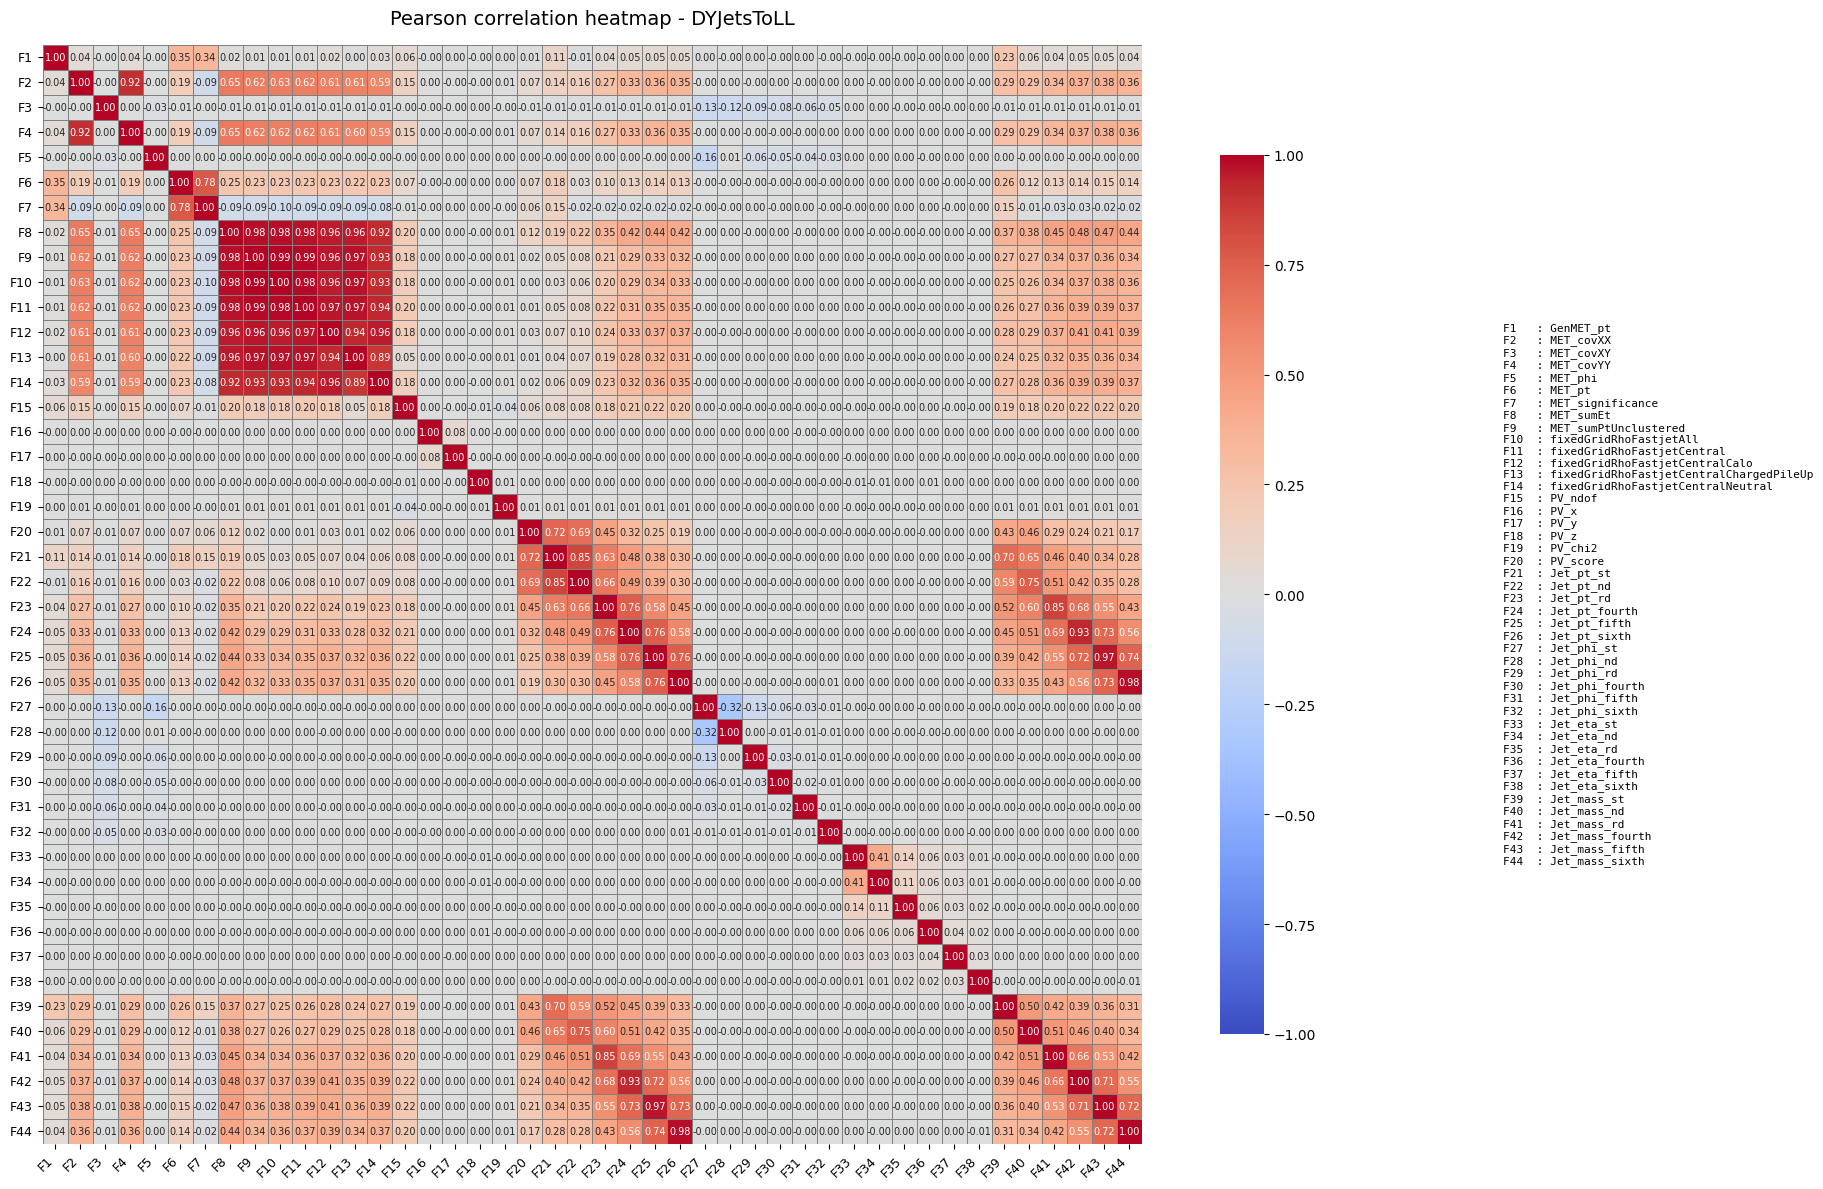

In [10]:
_correlation_heatmap(df, label, float_features)


Couples of features with spearman correlation > 0.70:
MET_covYY, MET_covXX = 0.93
MET_significance, MET_pt = 0.92
MET_sumEt, MET_covXX = 0.91
MET_sumEt, MET_covYY = 0.91
MET_sumPtUnclustered, MET_covXX = 0.89
MET_sumPtUnclustered, MET_covYY = 0.88
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_covXX = 0.89
fixedGridRhoFastjetAll, MET_covYY = 0.89
fixedGridRhoFastjetAll, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_covXX = 0.88
fixedGridRhoFastjetCentral, MET_covYY = 0.88
fixedGridRhoFastjetCentral, MET_sumEt = 0.97
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_covXX = 0.87
fixedGridRhoFastjetCentralCalo, MET_covYY = 0.87
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.96
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetAll = 0.96
fixedGridRhoFastjet

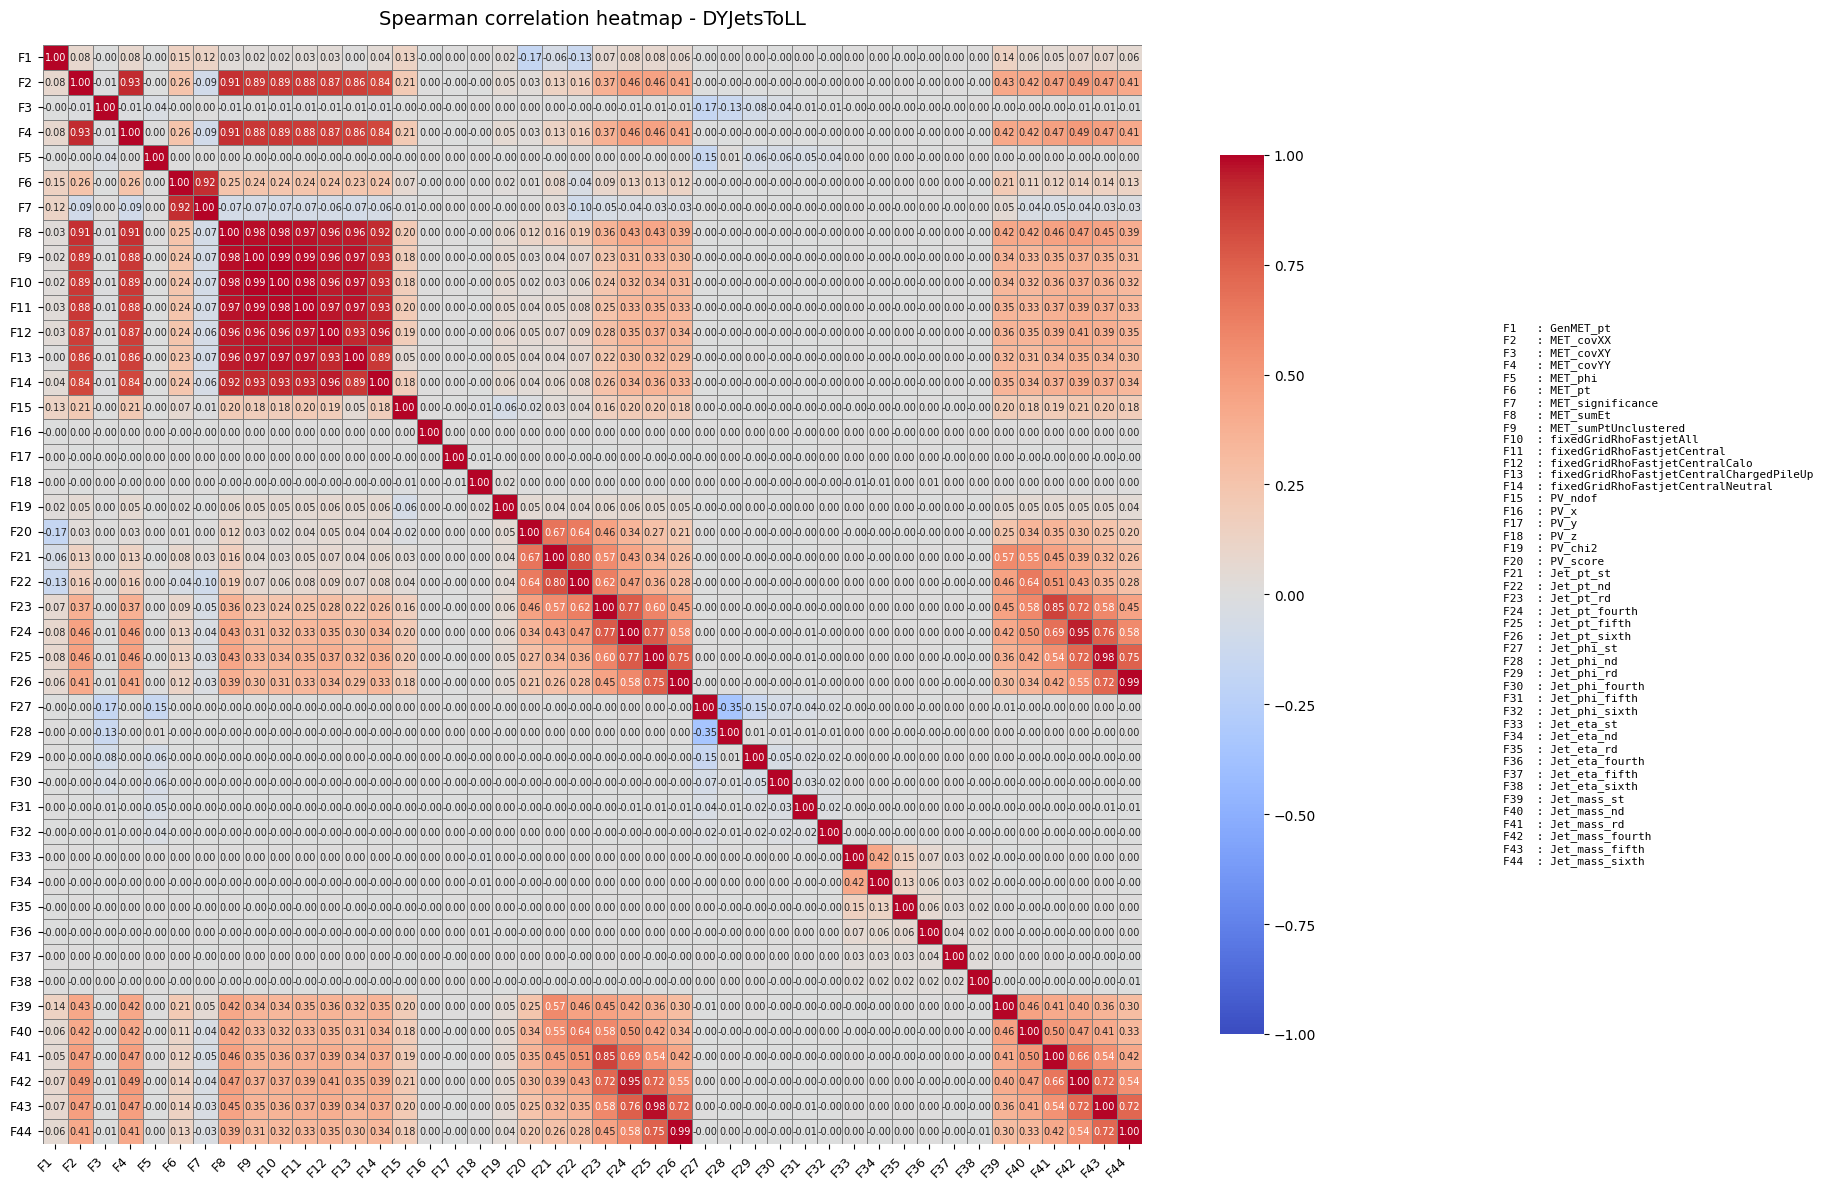

In [11]:
_correlation_heatmap(df, label, float_features, method="spearman")

Statistics for dataset DYJetsToLL:
  MET_pt:
count    571928.000000
mean         29.706693
std          18.957390
min           0.036261
25%          16.250637
50%          26.218985
75%          39.035298
max         423.591766
Name: MET_pt, dtype: float64

  GenMET_pt:
count    5.719280e+05
mean     6.071418e+00
std      1.272132e+01
min      5.630912e-15
25%      1.447042e-07
50%      1.201406e-06
75%      6.988281e+00
max      3.857500e+02
Name: GenMET_pt, dtype: float64


/home/matilde/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


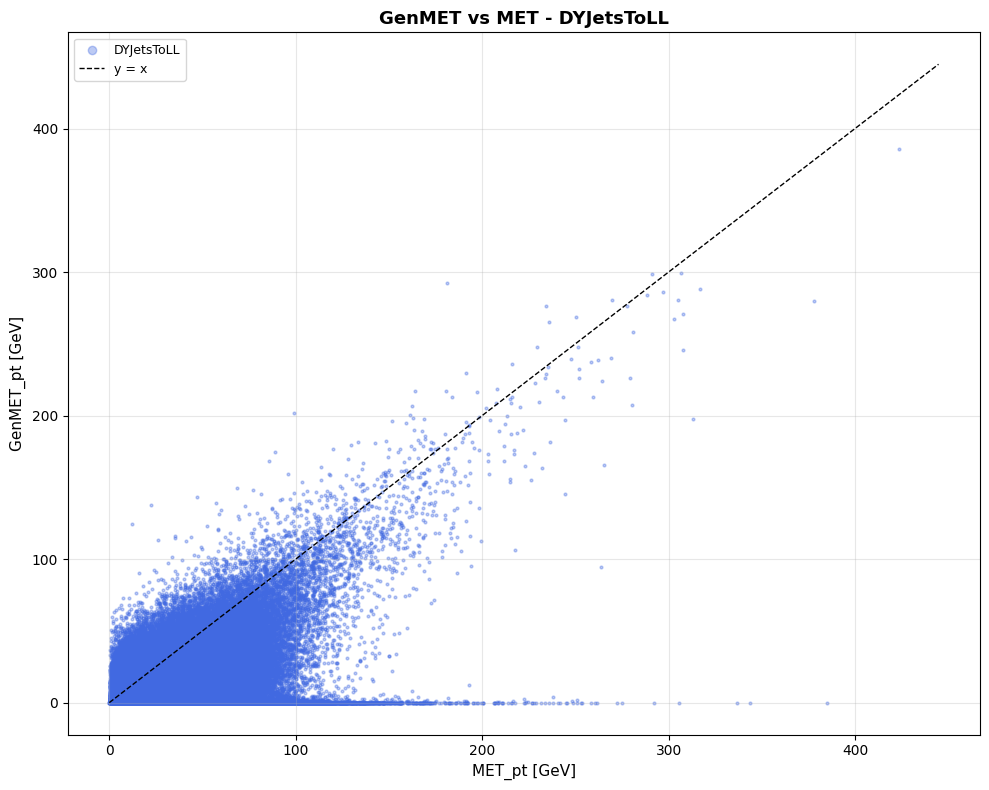

In [12]:
_scatterplot_MET(df, label=label, color=color)

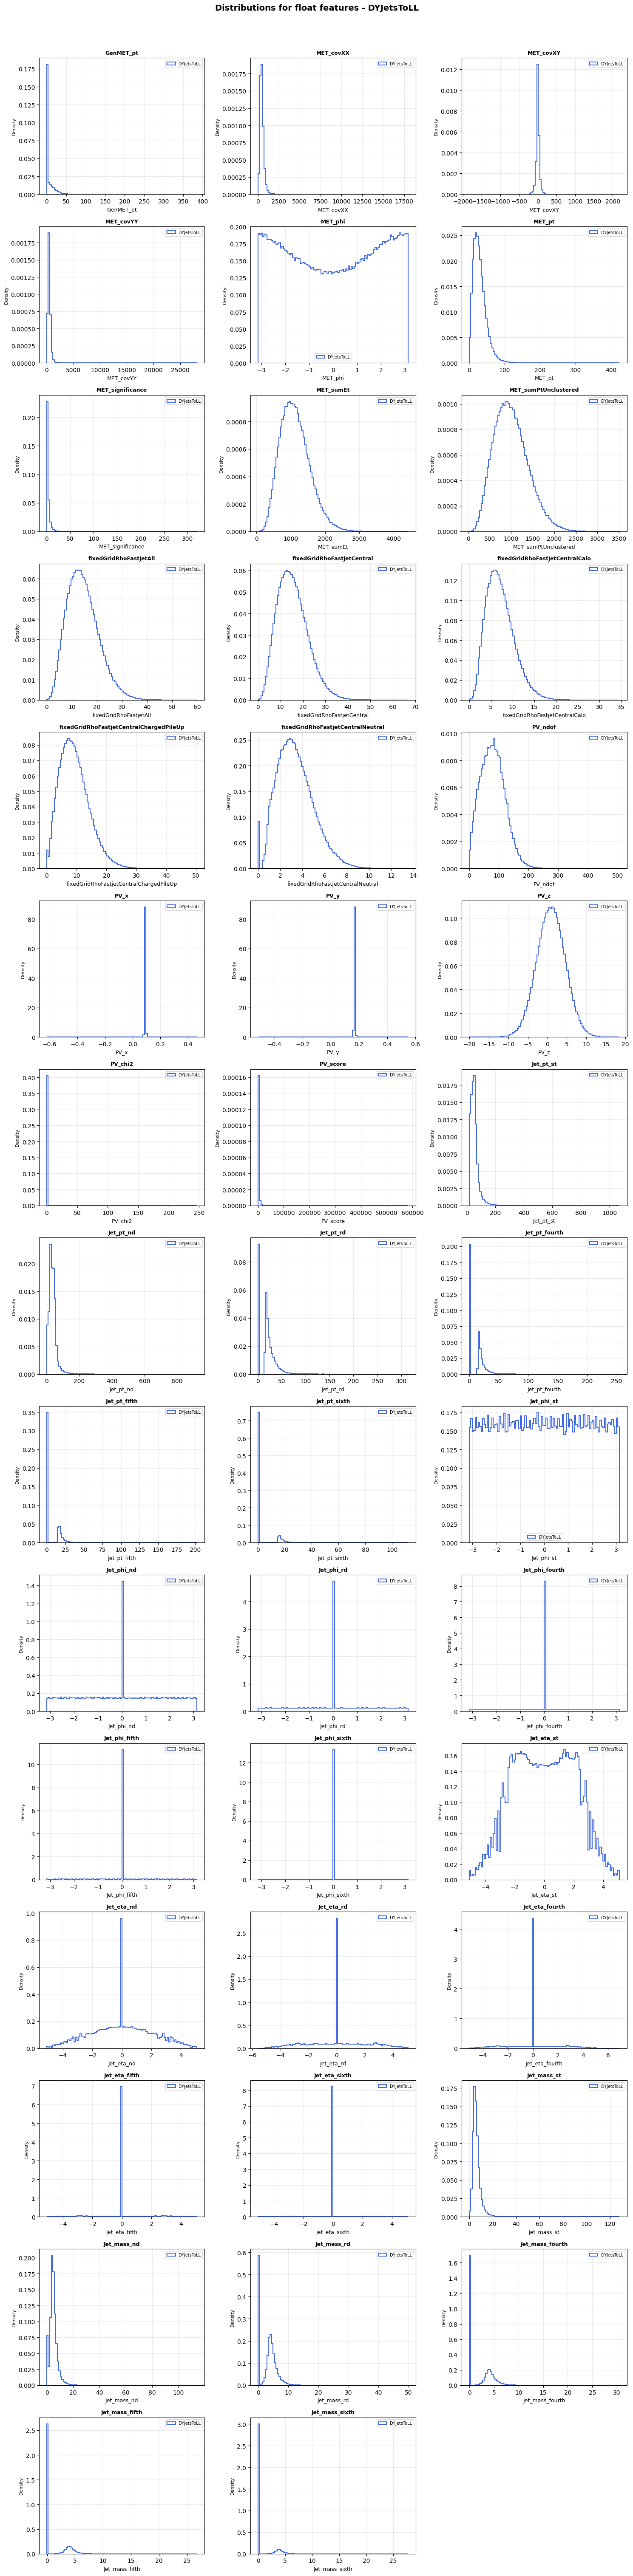

In [13]:
_data_distributions(df, float_features, label=label, color=color)

Outliers - DYJetsToLL
  GenMET_pt             72137 outliers (12.61%)
  MET_covXX             22369 outliers (3.91%)
  MET_covXY             56224 outliers (9.83%)
  MET_covYY             22309 outliers (3.90%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                15879 outliers (2.78%)
  MET_significance      39246 outliers (6.86%)
  MET_sumEt              6476 outliers (1.13%)
  MET_sumPtUnclustered   5635 outliers (0.99%)
  fixedGridRhoFastjetAll   6686 outliers (1.17%)
  fixedGridRhoFastjetCentral   6727 outliers (1.18%)
  fixedGridRhoFastjetCentralCalo   8139 outliers (1.42%)
  fixedGridRhoFastjetCentralChargedPileUp   7807 outliers (1.37%)
  fixedGridRhoFastjetCentralNeutral   6644 outliers (1.16%)
  PV_ndof                3506 outliers (0.61%)
  PV_x                  19984 outliers (3.49%)
  PV_y                  17916 outliers (3.13%)
  PV_z                   4049 outliers (0.71%)
  PV_chi2               19093 outliers (3.34%)
  PV_score              34504 outl

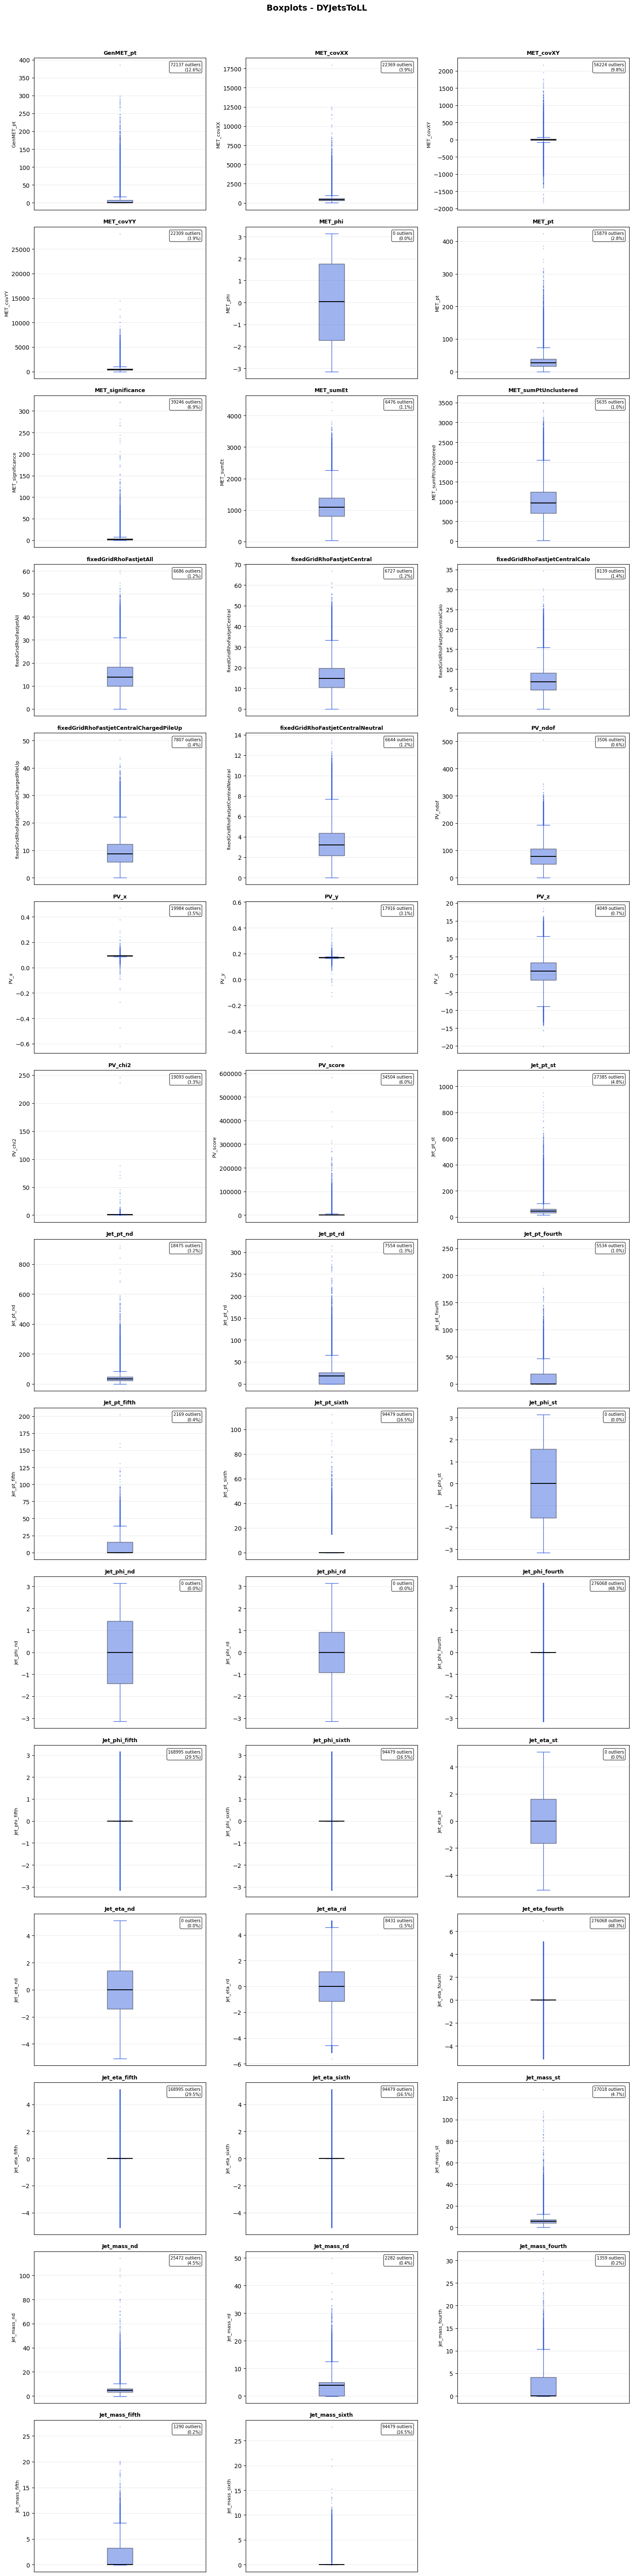

In [14]:
_boxplots(df, float_features, label=label, color=color)

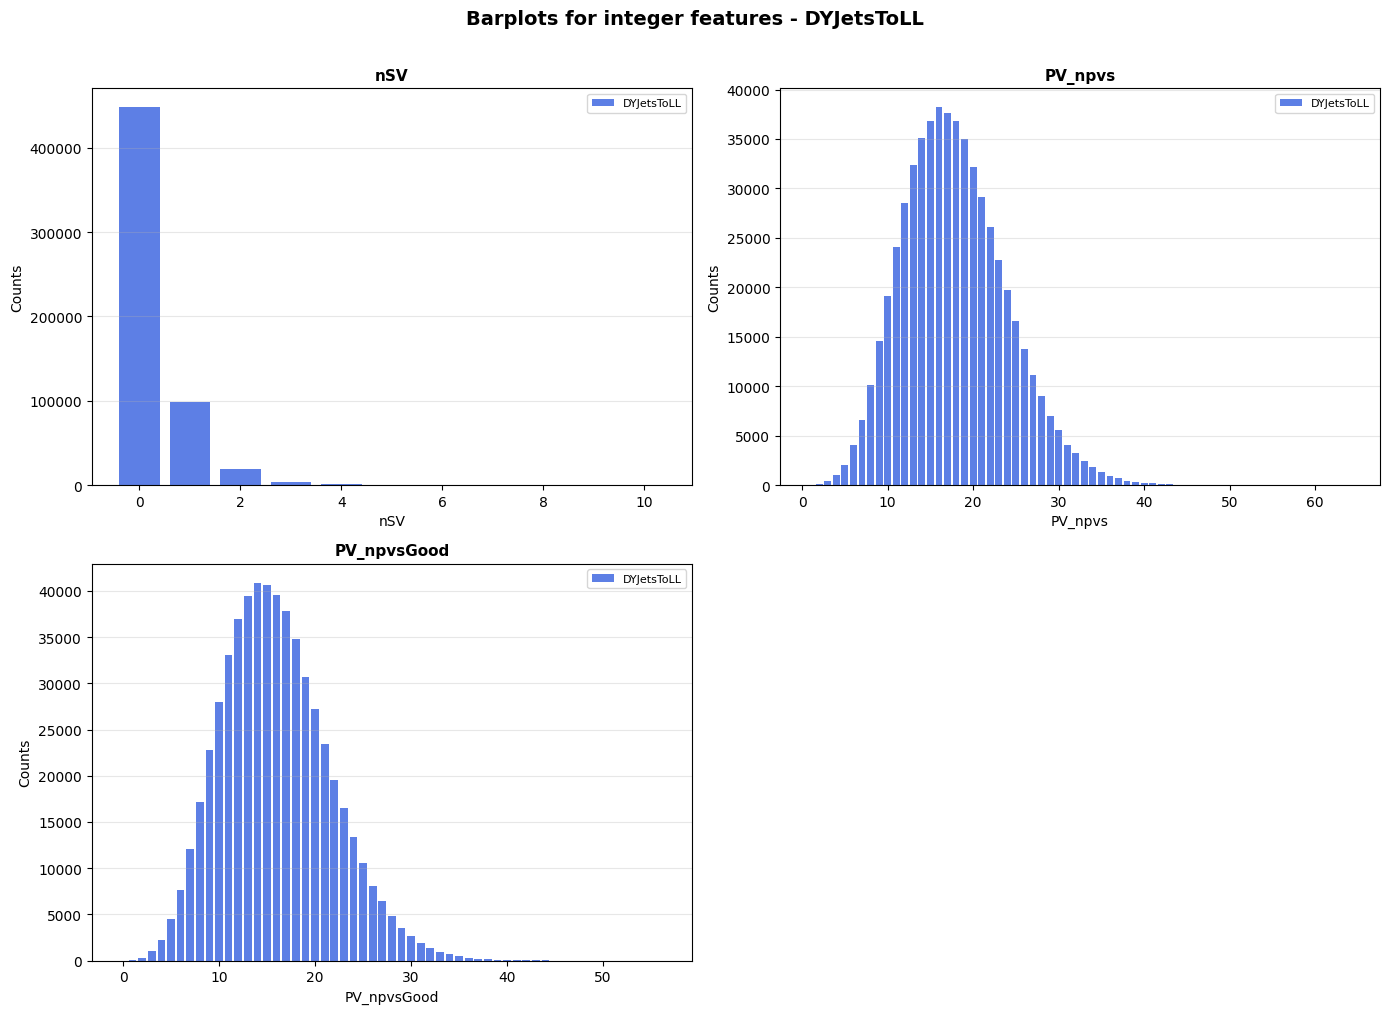

In [15]:
_data_barplots(df, label=label, color=color)

---

## HToAATo2Mu2B dataset

In [16]:
label = list(DATASETS.items())[1][0]
path = DATASETS.get("HToAATo2Mu2B")
color = PALETTE[1]

df, float_features, int_features = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Auto-detected 44 float features, 4 int features
Dataset HToAATo2Mu2B:
    48 features x 198788 events



Couples of features with pearson correlation > 0.70:
MET_covYY, MET_covXX = 0.91
MET_significance, MET_pt = 0.78
MET_sumEt, MET_covXX = 0.76
MET_sumEt, MET_covYY = 0.75
MET_sumPtUnclustered, MET_covXX = 0.72
MET_sumPtUnclustered, MET_covYY = 0.72
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_covXX = 0.73
fixedGridRhoFastjetAll, MET_covYY = 0.72
fixedGridRhoFastjetAll, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_covXX = 0.72
fixedGridRhoFastjetCentral, MET_covYY = 0.72
fixedGridRhoFastjetCentral, MET_sumEt = 0.97
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.98
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_covXX = 0.71
fixedGridRhoFastjetCentralCalo, MET_covYY = 0.71
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.96
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetAll = 0.96
fixedGridRhoFastjetC

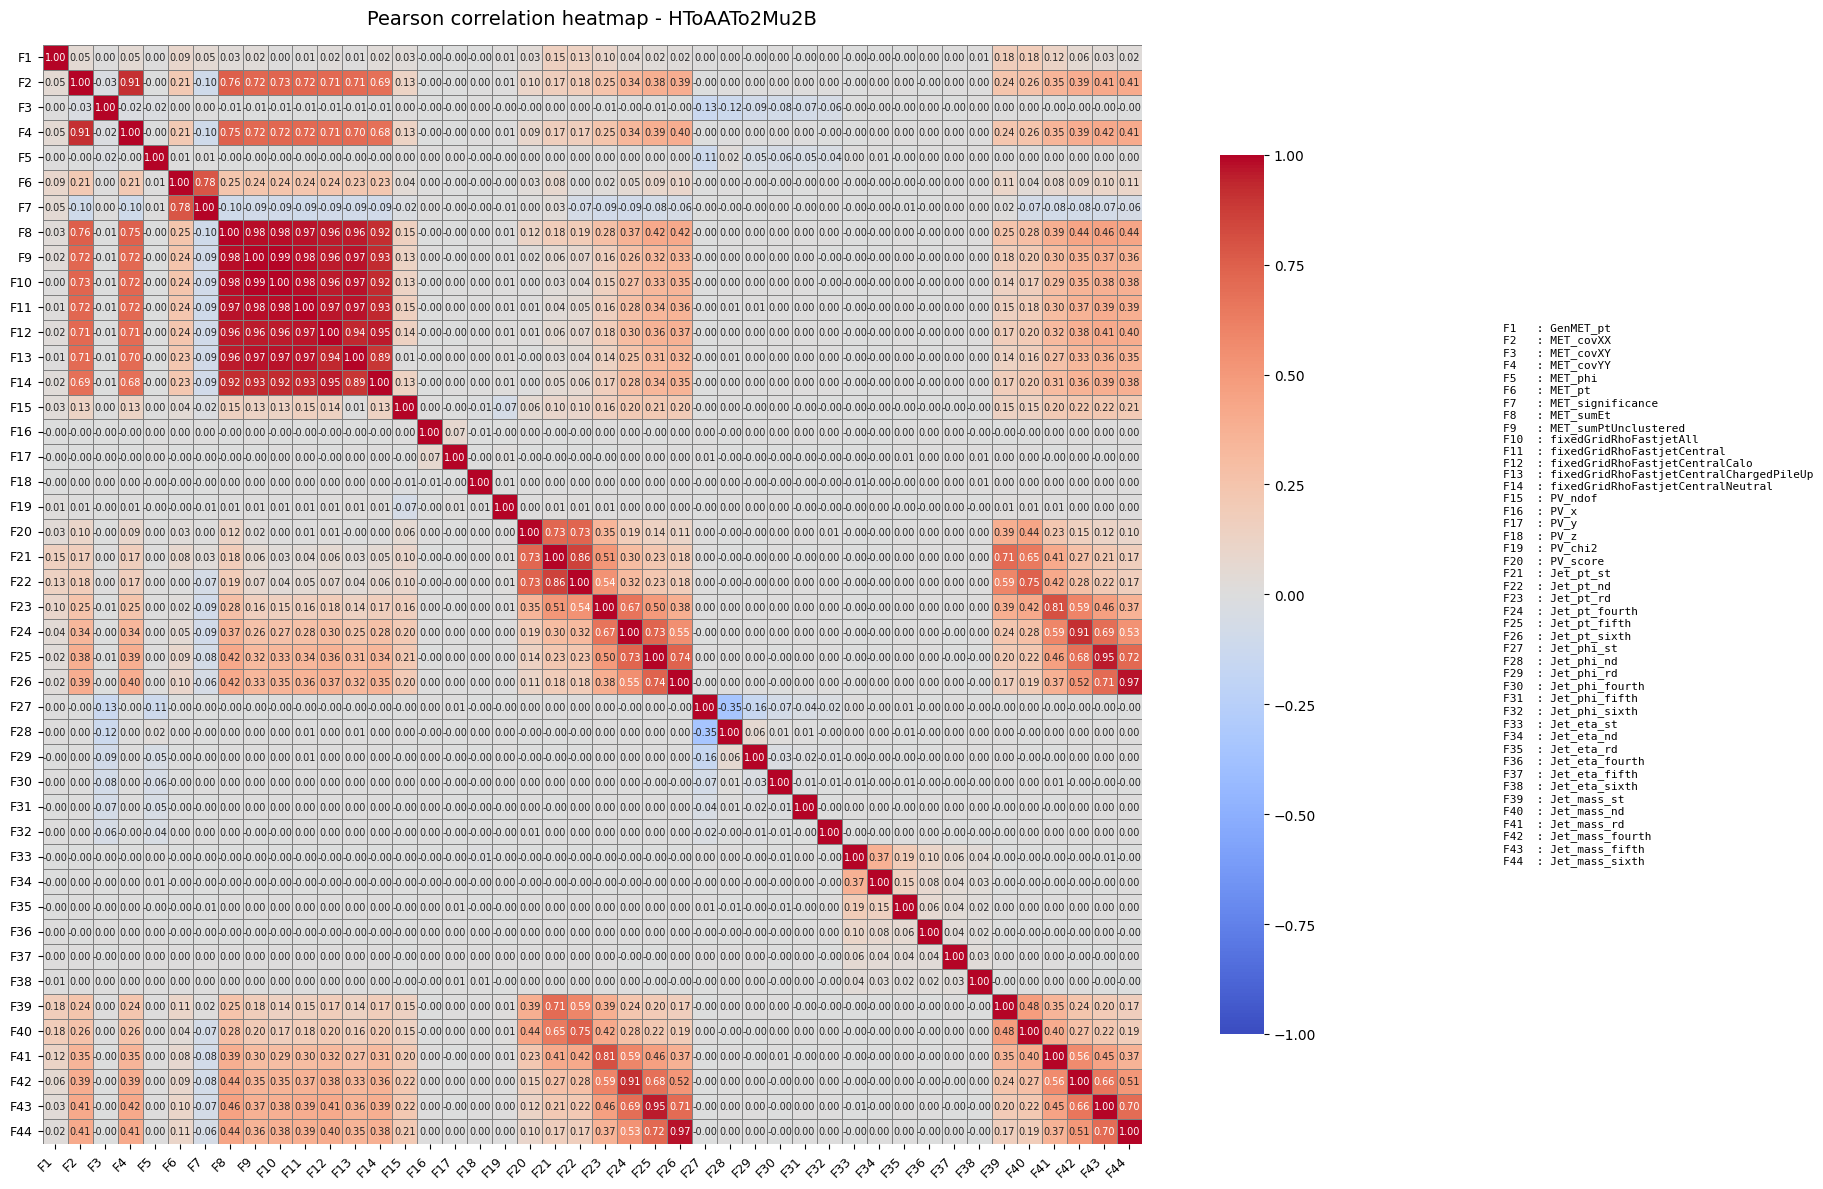

In [17]:
_correlation_heatmap(df, label, float_features)


Couples of features with spearman correlation > 0.70:
MET_covYY, MET_covXX = 0.92
MET_significance, MET_pt = 0.92
MET_sumEt, MET_covXX = 0.92
MET_sumEt, MET_covYY = 0.92
MET_sumPtUnclustered, MET_covXX = 0.89
MET_sumPtUnclustered, MET_covYY = 0.89
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_covXX = 0.90
fixedGridRhoFastjetAll, MET_covYY = 0.90
fixedGridRhoFastjetAll, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_covXX = 0.89
fixedGridRhoFastjetCentral, MET_covYY = 0.89
fixedGridRhoFastjetCentral, MET_sumEt = 0.97
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.98
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_covXX = 0.88
fixedGridRhoFastjetCentralCalo, MET_covYY = 0.87
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.96
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetAll = 0.96
fixedGridRhoFastjet

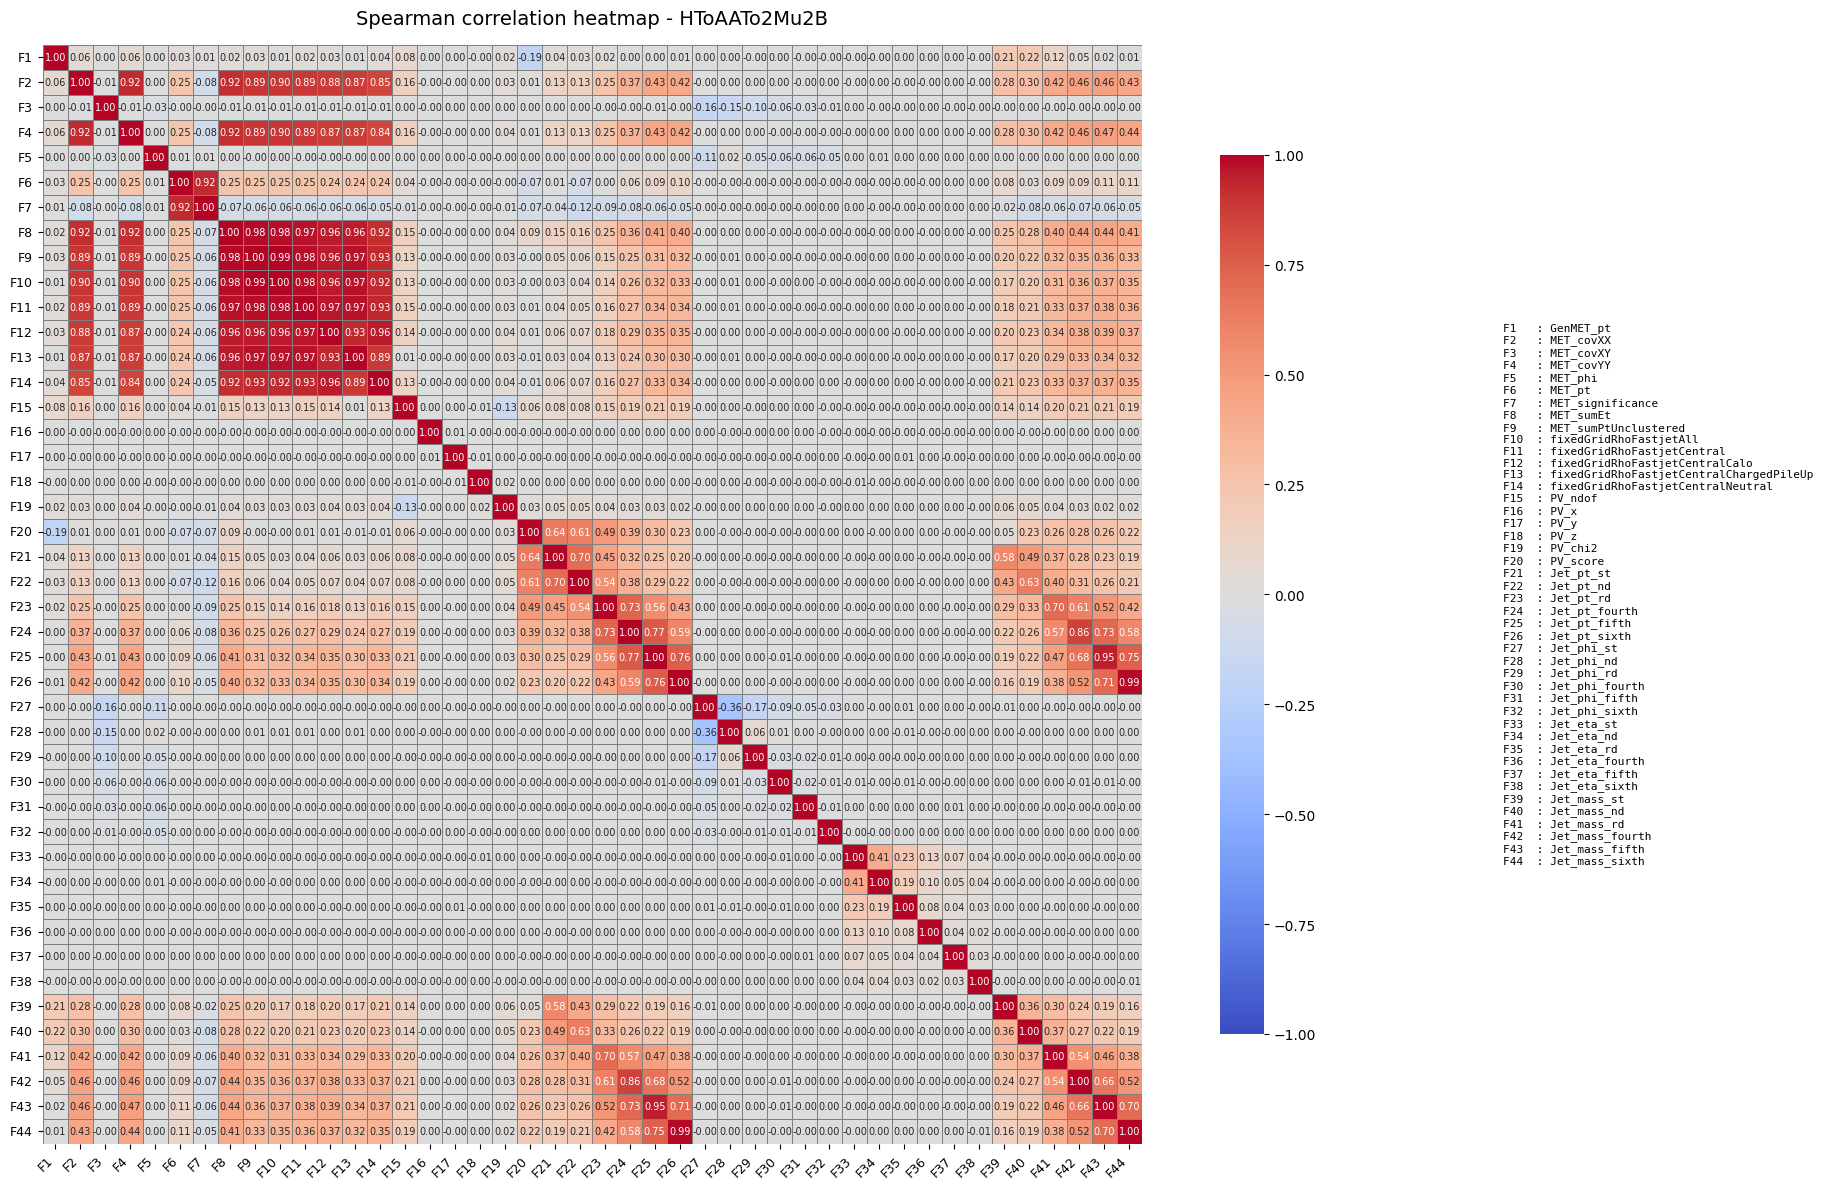

In [18]:
_correlation_heatmap(df, label, float_features, method="spearman")

Statistics for dataset HToAATo2Mu2B:
  MET_pt:
count    198788.000000
mean         28.686183
std          17.806917
min           0.074594
25%          15.894227
50%          25.432565
75%          37.754591
max         633.434509
Name: MET_pt, dtype: float64

  GenMET_pt:
count    1.987880e+05
mean     4.088678e+00
std      6.376928e+00
min      1.122019e-14
25%      3.521109e-09
50%      1.455078e+00
75%      5.753906e+00
max      2.020000e+02
Name: GenMET_pt, dtype: float64


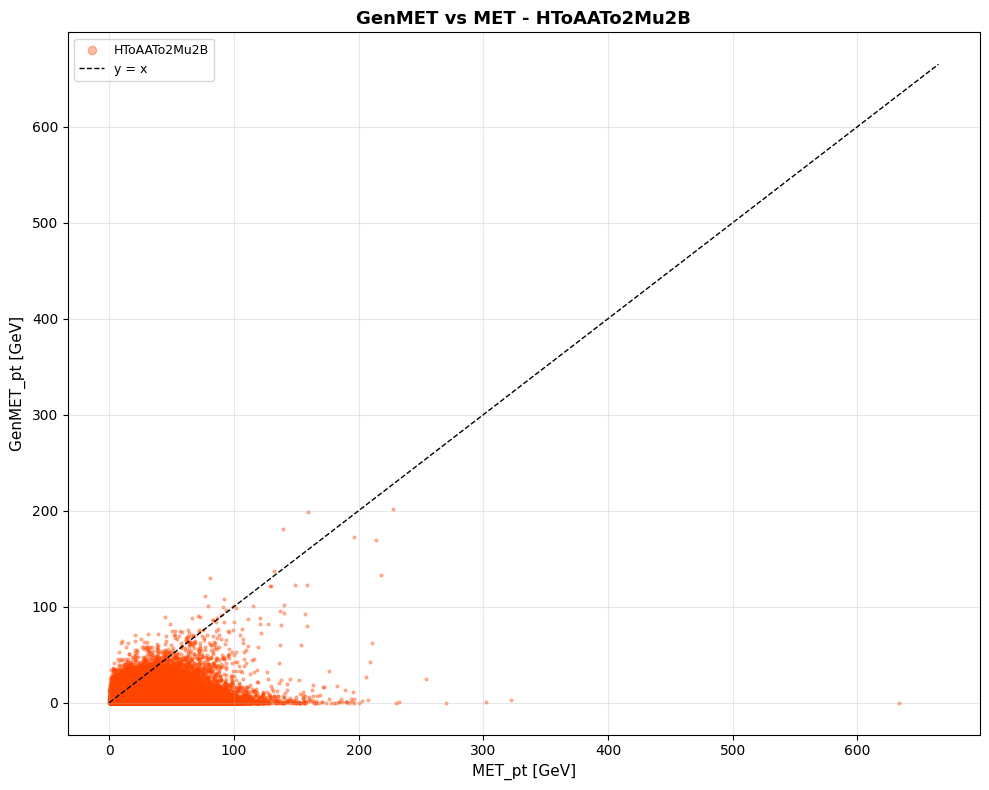

In [19]:
_scatterplot_MET(df, label=label, color=color)

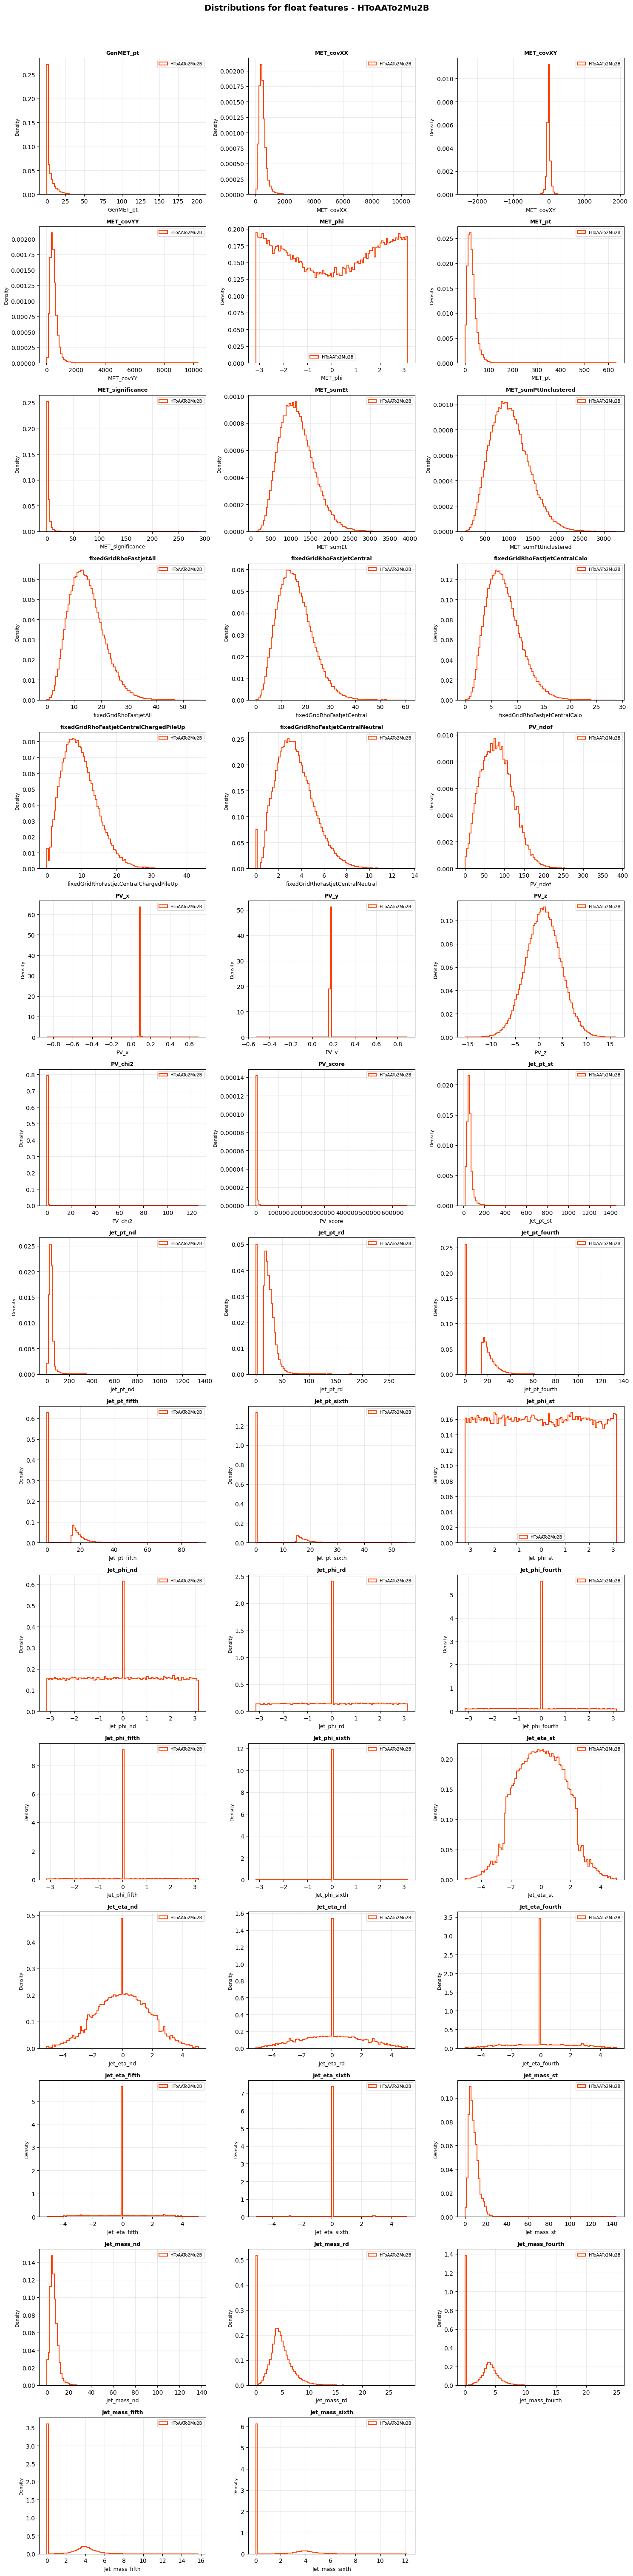

In [20]:
_data_distributions(df, float_features, label=label, color=color)

Outliers - HToAATo2Mu2B
  GenMET_pt             13666 outliers (6.87%)
  MET_covXX              7211 outliers (3.63%)
  MET_covXY             15442 outliers (7.77%)
  MET_covYY              7156 outliers (3.60%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                 5338 outliers (2.69%)
  MET_significance      13539 outliers (6.81%)
  MET_sumEt              2140 outliers (1.08%)
  MET_sumPtUnclustered   1845 outliers (0.93%)
  fixedGridRhoFastjetAll   2203 outliers (1.11%)
  fixedGridRhoFastjetCentral   2189 outliers (1.10%)
  fixedGridRhoFastjetCentralCalo   2632 outliers (1.32%)
  fixedGridRhoFastjetCentralChargedPileUp   2425 outliers (1.22%)
  fixedGridRhoFastjetCentralNeutral   2283 outliers (1.15%)
  PV_ndof                1223 outliers (0.62%)
  PV_x                   6734 outliers (3.39%)
  PV_y                   7552 outliers (3.80%)
  PV_z                   1338 outliers (0.67%)
  PV_chi2                6114 outliers (3.08%)
  PV_score               7529 out

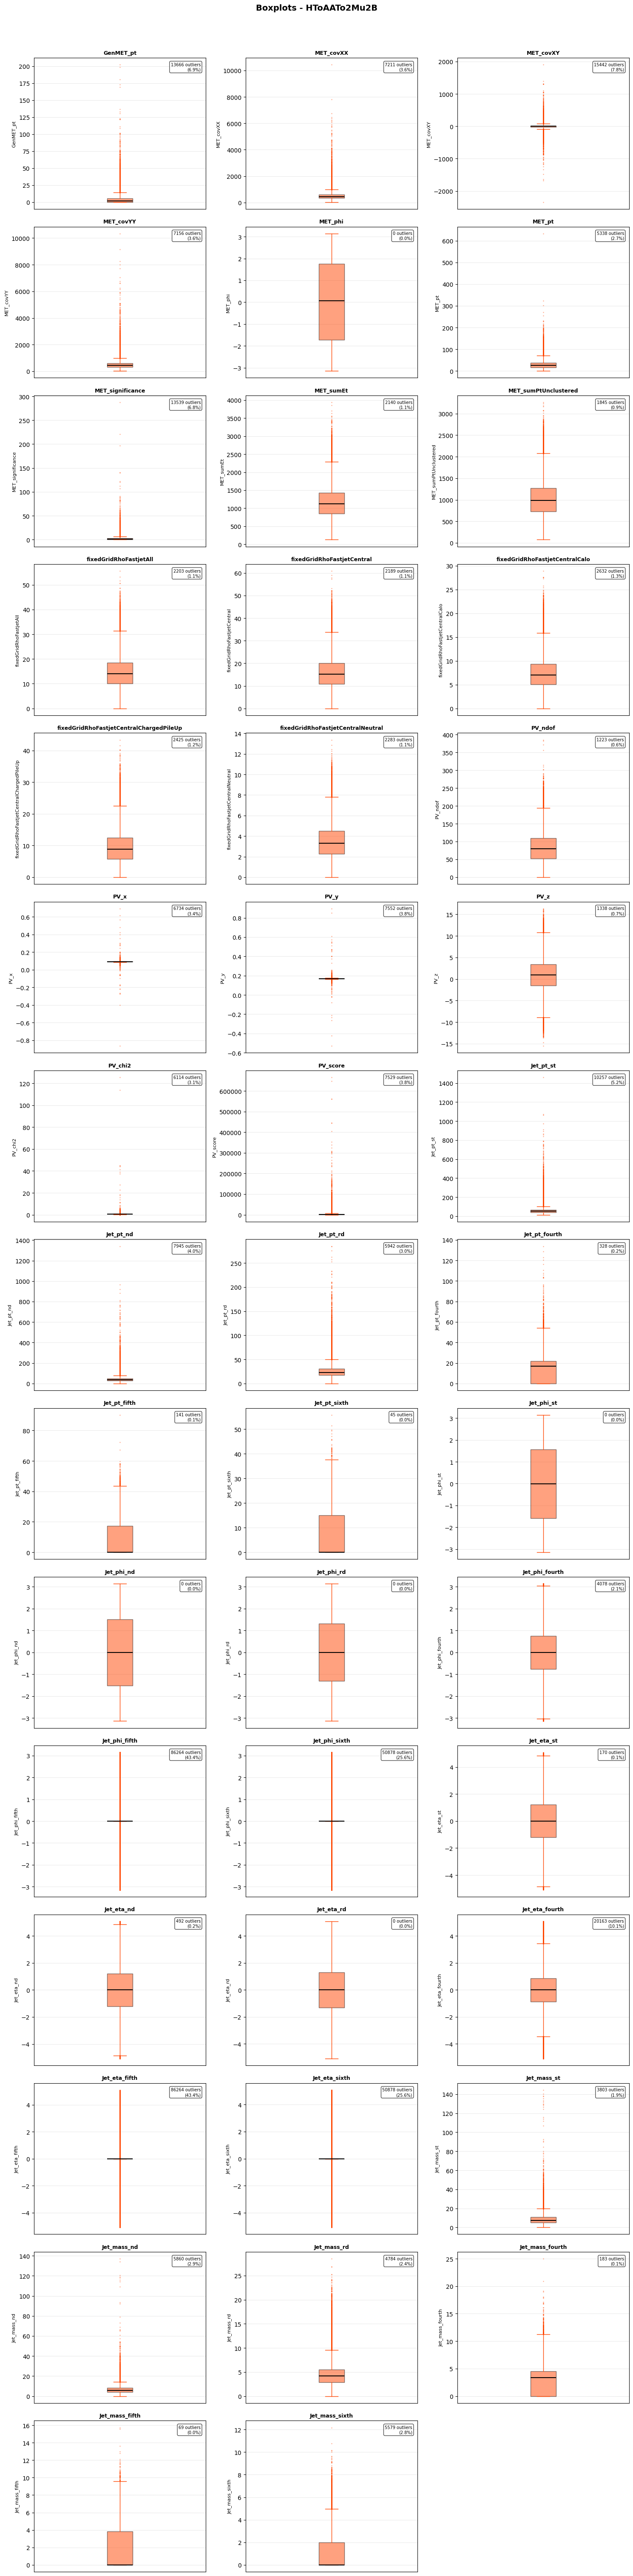

In [21]:
_boxplots(df, float_features, label=label, color=color)

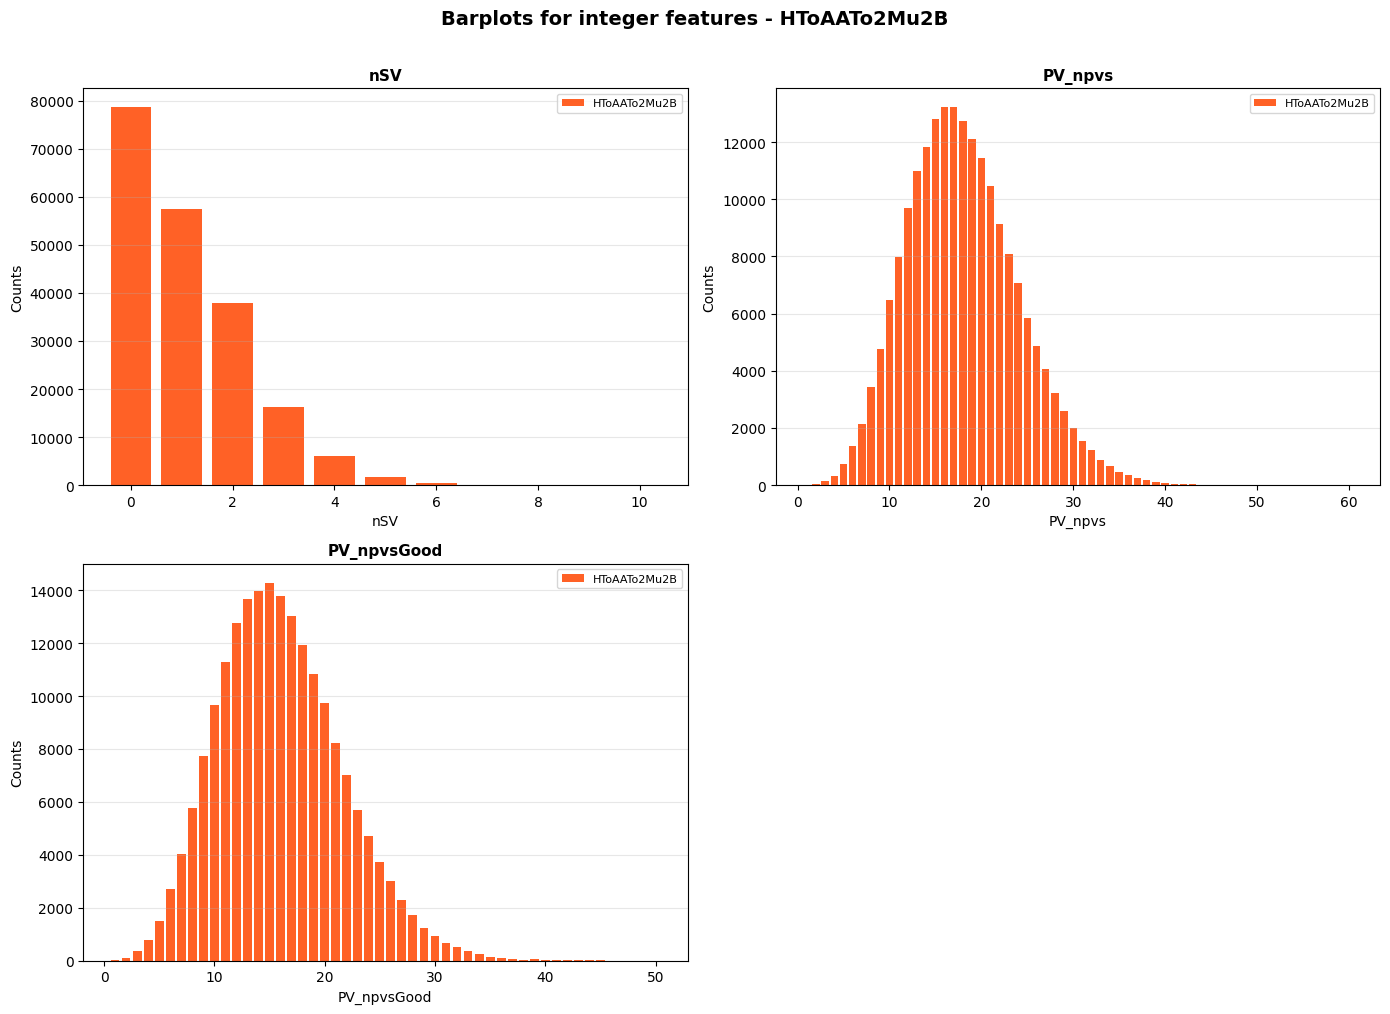

In [22]:
_data_barplots(df, label=label, color=color)

---

## ZZTo2L2Nu dataset

In [23]:
label = list(DATASETS.items())[2][0]
path = DATASETS.get("ZZTo2L2Nu")
color = PALETTE[2]

df, float_features, int_features = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Auto-detected 44 float features, 4 int features
Dataset ZZTo2L2Nu:
    48 features x 158930 events



Couples of features with pearson correlation > 0.70:
MET_covYY, MET_covXX = 0.91
MET_pt, GenMET_pt = 0.89
MET_significance, MET_pt = 0.71
MET_sumEt, MET_covXX = 0.78
MET_sumEt, MET_covYY = 0.78
MET_sumPtUnclustered, MET_covXX = 0.74
MET_sumPtUnclustered, MET_covYY = 0.75
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_covXX = 0.75
fixedGridRhoFastjetAll, MET_covYY = 0.76
fixedGridRhoFastjetAll, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_covXX = 0.74
fixedGridRhoFastjetCentral, MET_covYY = 0.75
fixedGridRhoFastjetCentral, MET_sumEt = 0.97
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_covXX = 0.73
fixedGridRhoFastjetCentralCalo, MET_covYY = 0.74
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.95
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCentralCalo, fixedGridRhoFastjetAll = 

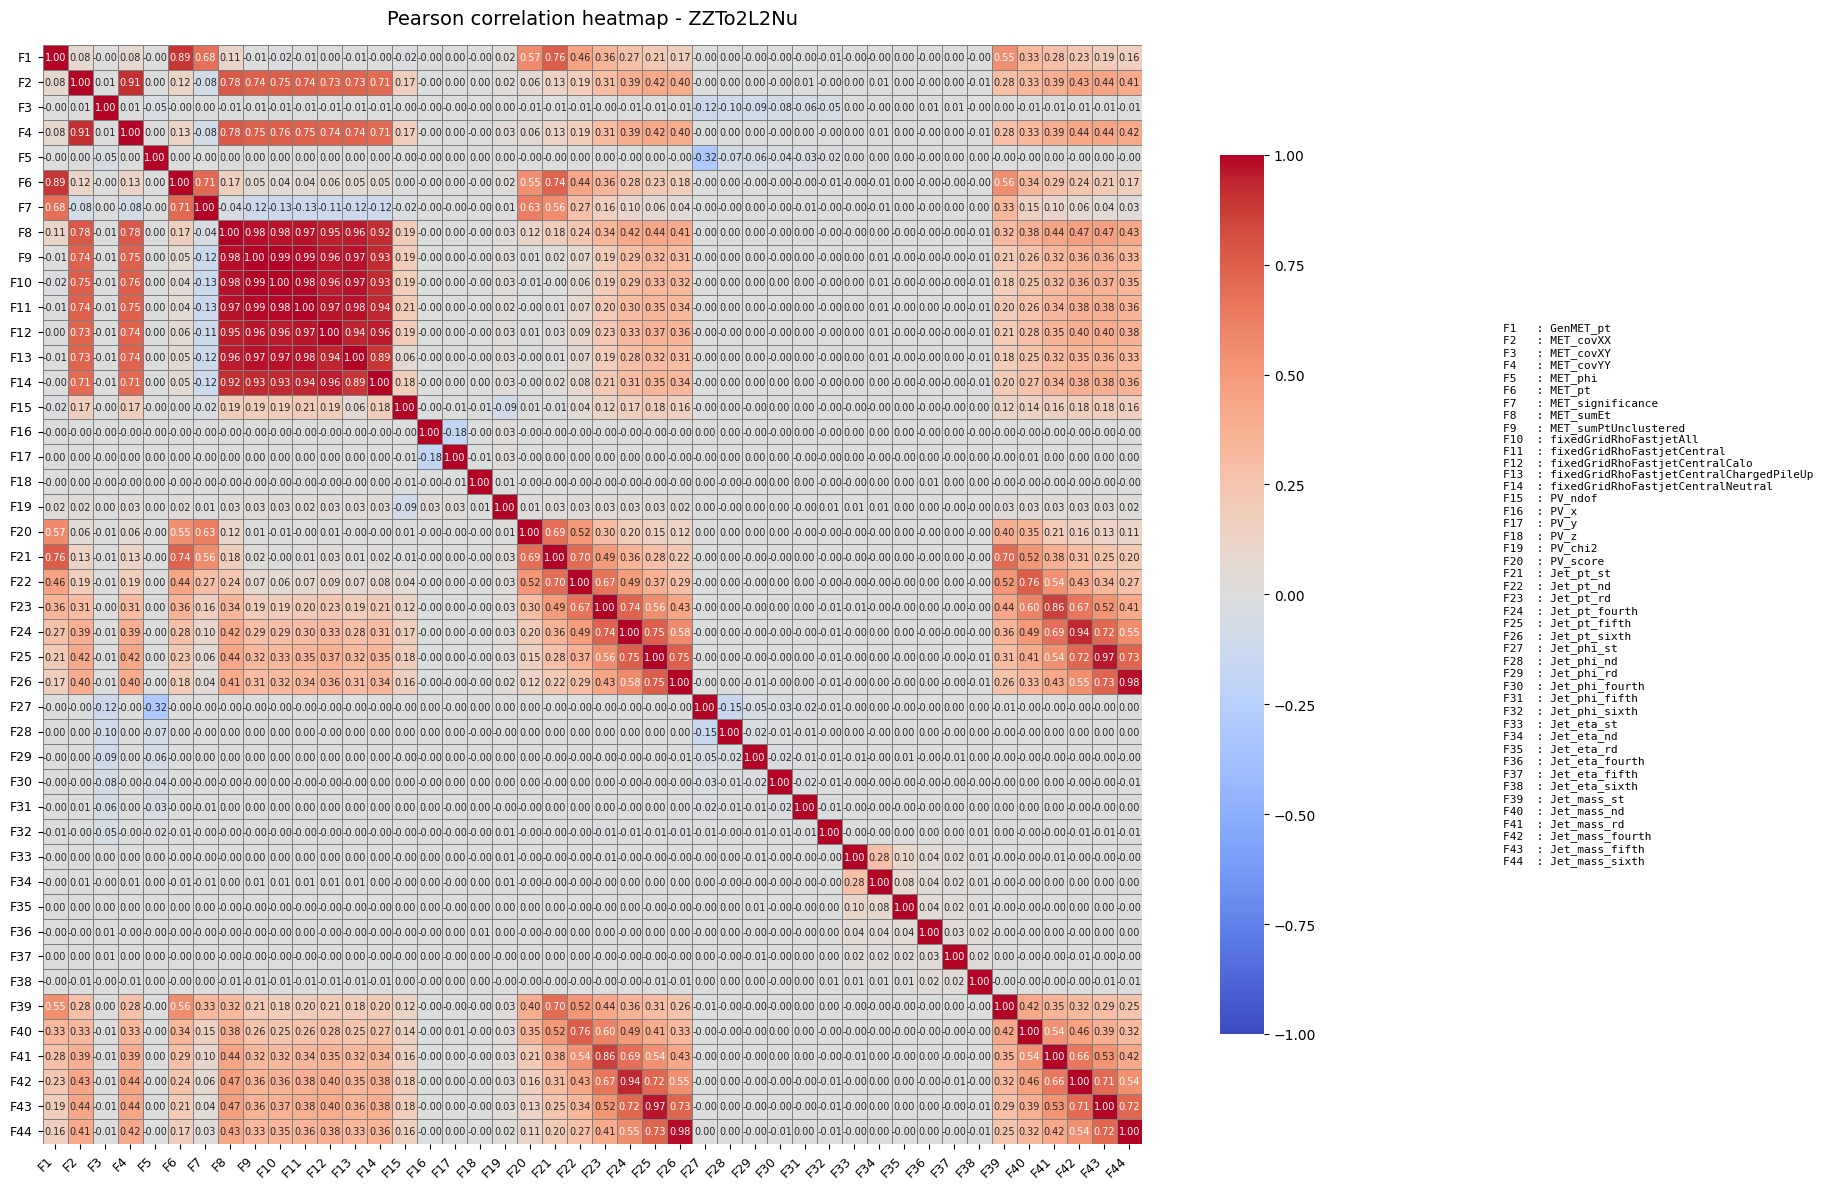

In [24]:
_correlation_heatmap(df, label, float_features)


Couples of features with spearman correlation > 0.70:
MET_covYY, MET_covXX = 0.93
MET_pt, GenMET_pt = 0.74
MET_significance, GenMET_pt = 0.72
MET_significance, MET_pt = 0.94
MET_sumEt, MET_covXX = 0.92
MET_sumEt, MET_covYY = 0.92
MET_sumPtUnclustered, MET_covXX = 0.90
MET_sumPtUnclustered, MET_covYY = 0.90
MET_sumPtUnclustered, MET_sumEt = 0.98
fixedGridRhoFastjetAll, MET_covXX = 0.90
fixedGridRhoFastjetAll, MET_covYY = 0.90
fixedGridRhoFastjetAll, MET_sumEt = 0.97
fixedGridRhoFastjetAll, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, MET_covXX = 0.90
fixedGridRhoFastjetCentral, MET_covYY = 0.90
fixedGridRhoFastjetCentral, MET_sumEt = 0.97
fixedGridRhoFastjetCentral, MET_sumPtUnclustered = 0.99
fixedGridRhoFastjetCentral, fixedGridRhoFastjetAll = 0.98
fixedGridRhoFastjetCentralCalo, MET_covXX = 0.88
fixedGridRhoFastjetCentralCalo, MET_covYY = 0.88
fixedGridRhoFastjetCentralCalo, MET_sumEt = 0.95
fixedGridRhoFastjetCentralCalo, MET_sumPtUnclustered = 0.96
fixedGridRhoFastjetCe

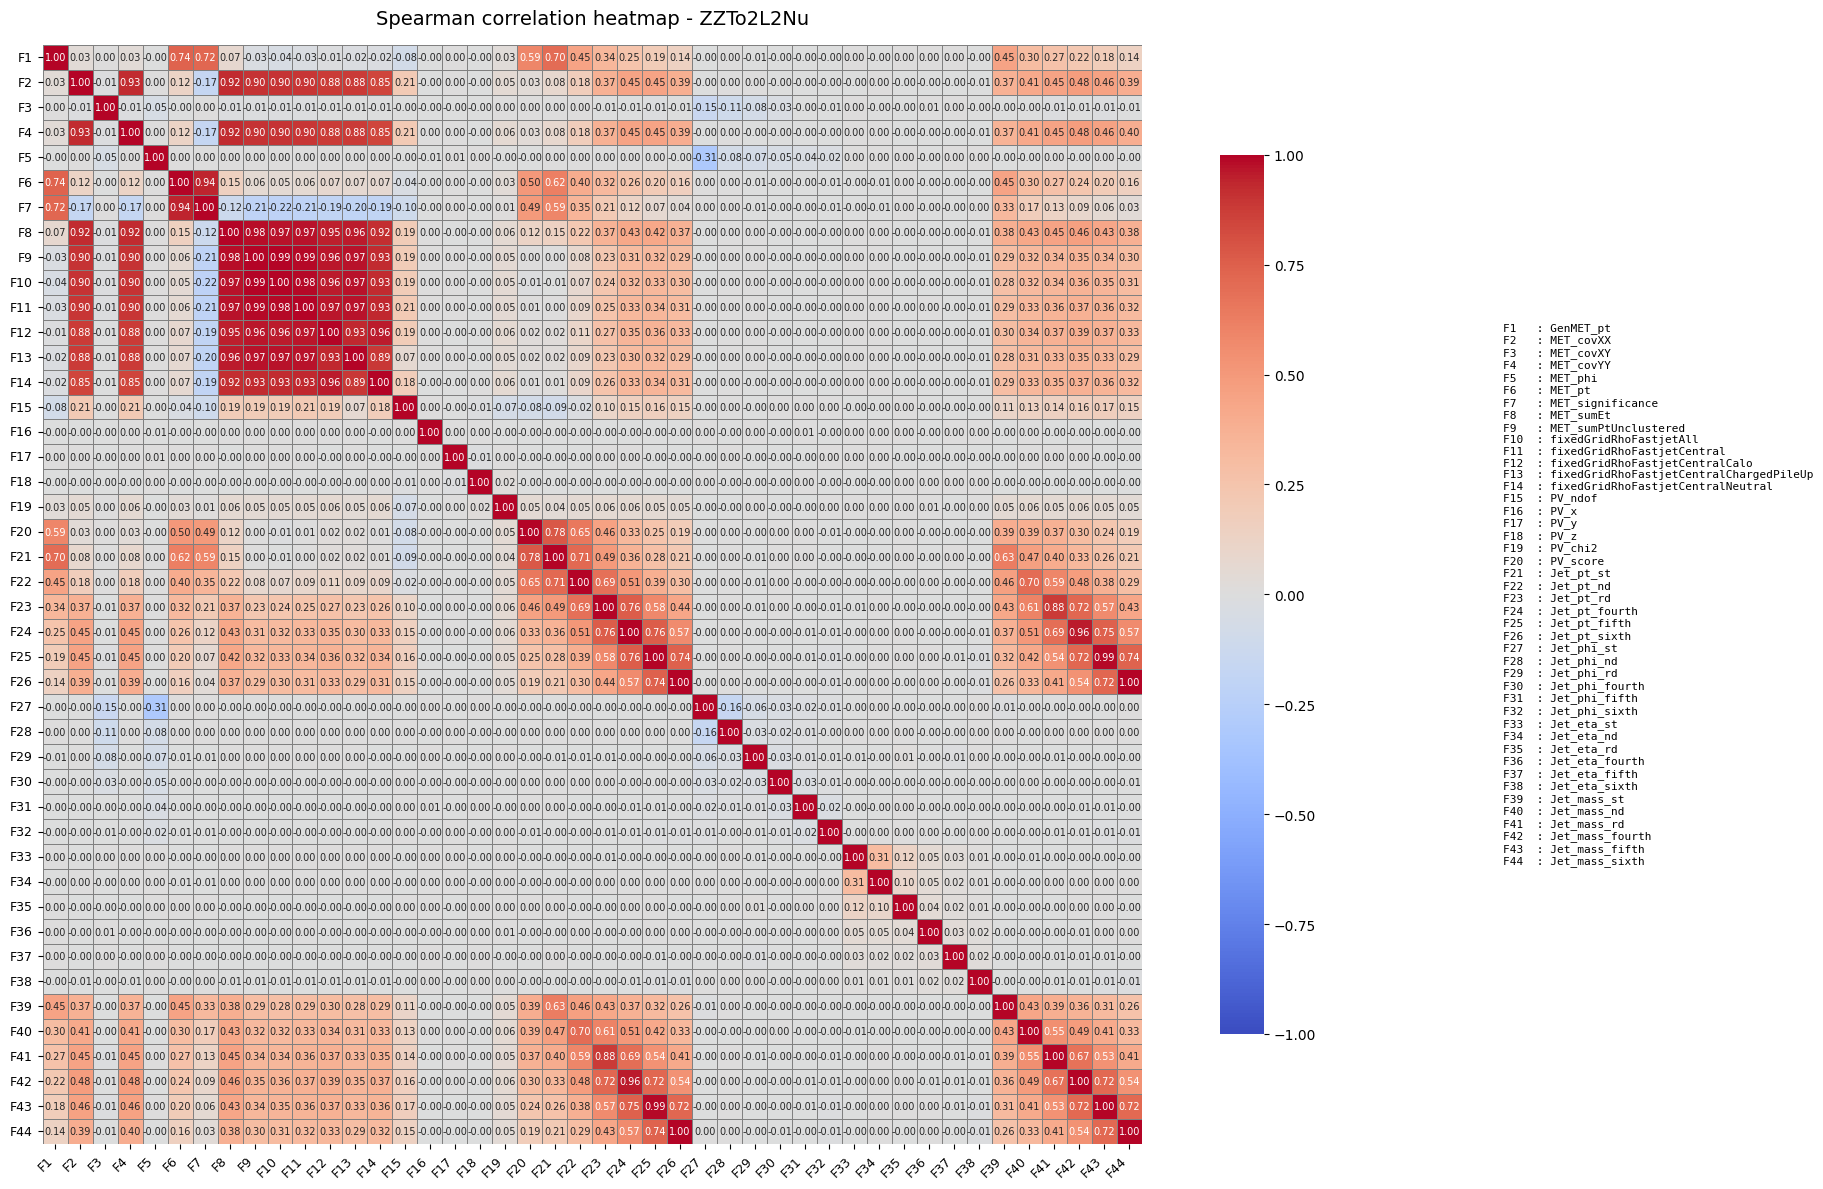

In [25]:
_correlation_heatmap(df, label, float_features, method="spearman")

Statistics for dataset ZZTo2L2Nu:
  MET_pt:
count    158930.000000
mean         56.308169
std          47.218994
min           0.134062
25%          26.613268
50%          44.426109
75%          71.317698
max        1064.584229
Name: MET_pt, dtype: float64

  GenMET_pt:
count    158930.000000
mean         48.674718
std          46.905228
min           0.024750
25%          18.828125
50%          35.968750
75%          62.750000
max         955.000000
Name: GenMET_pt, dtype: float64


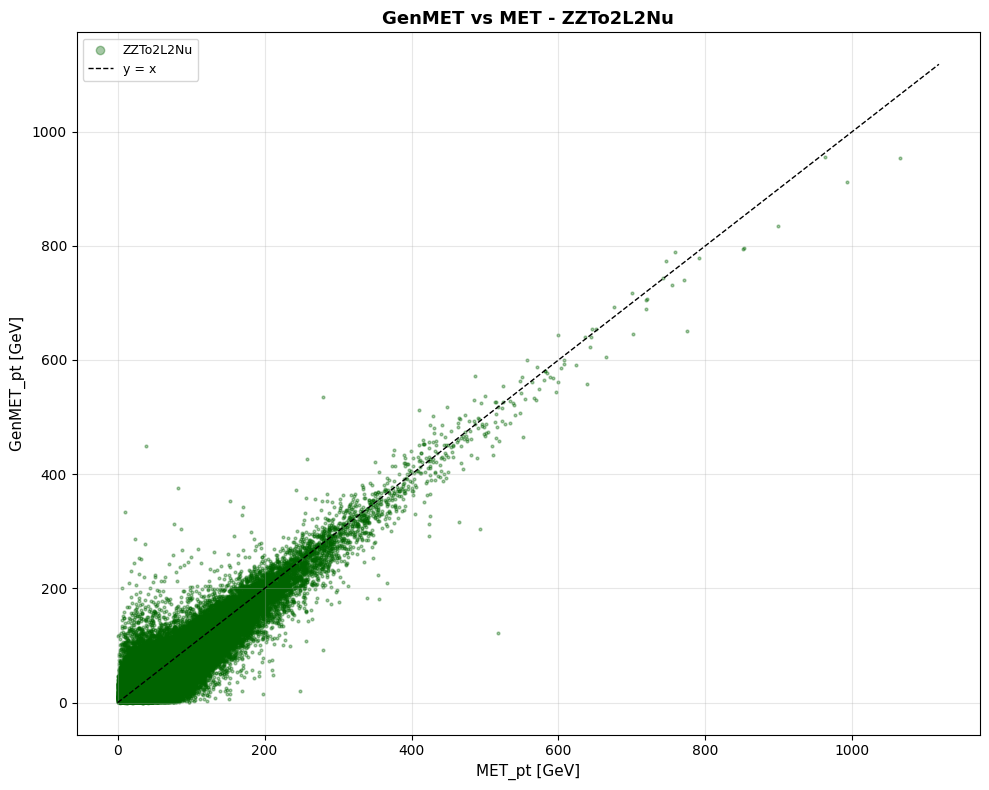

In [26]:
_scatterplot_MET(df, label=label, color=color)

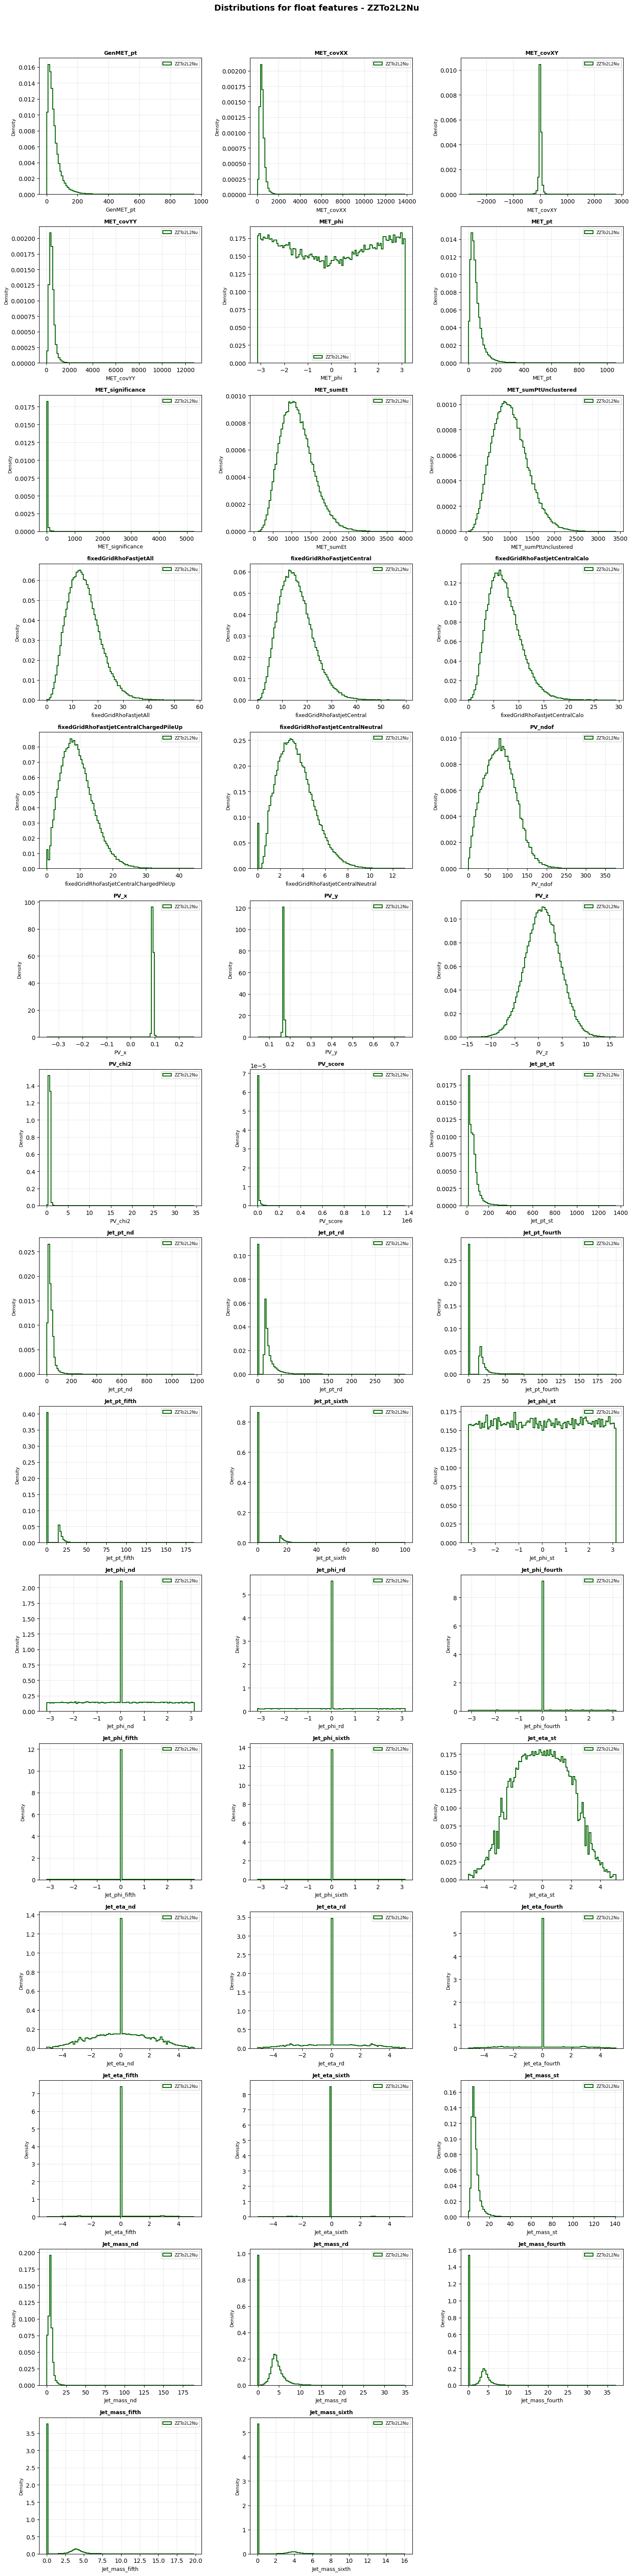

In [27]:
_data_distributions(df, float_features, label=label, color=color)

Outliers - ZZTo2L2Nu
  GenMET_pt              8751 outliers (5.51%)
  MET_covXX              5618 outliers (3.53%)
  MET_covXY             15786 outliers (9.93%)
  MET_covYY              5701 outliers (3.59%)
  MET_phi                   0 outliers (0.00%)
  MET_pt                 8390 outliers (5.28%)
  MET_significance      16239 outliers (10.22%)
  MET_sumEt              1892 outliers (1.19%)
  MET_sumPtUnclustered   1519 outliers (0.96%)
  fixedGridRhoFastjetAll   1848 outliers (1.16%)
  fixedGridRhoFastjetCentral   1869 outliers (1.18%)
  fixedGridRhoFastjetCentralCalo   2263 outliers (1.42%)
  fixedGridRhoFastjetCentralChargedPileUp   2207 outliers (1.39%)
  fixedGridRhoFastjetCentralNeutral   1906 outliers (1.20%)
  PV_ndof                 975 outliers (0.61%)
  PV_x                   4976 outliers (3.13%)
  PV_y                   5154 outliers (3.24%)
  PV_z                   1084 outliers (0.68%)
  PV_chi2                4732 outliers (2.98%)
  PV_score              15429 outli

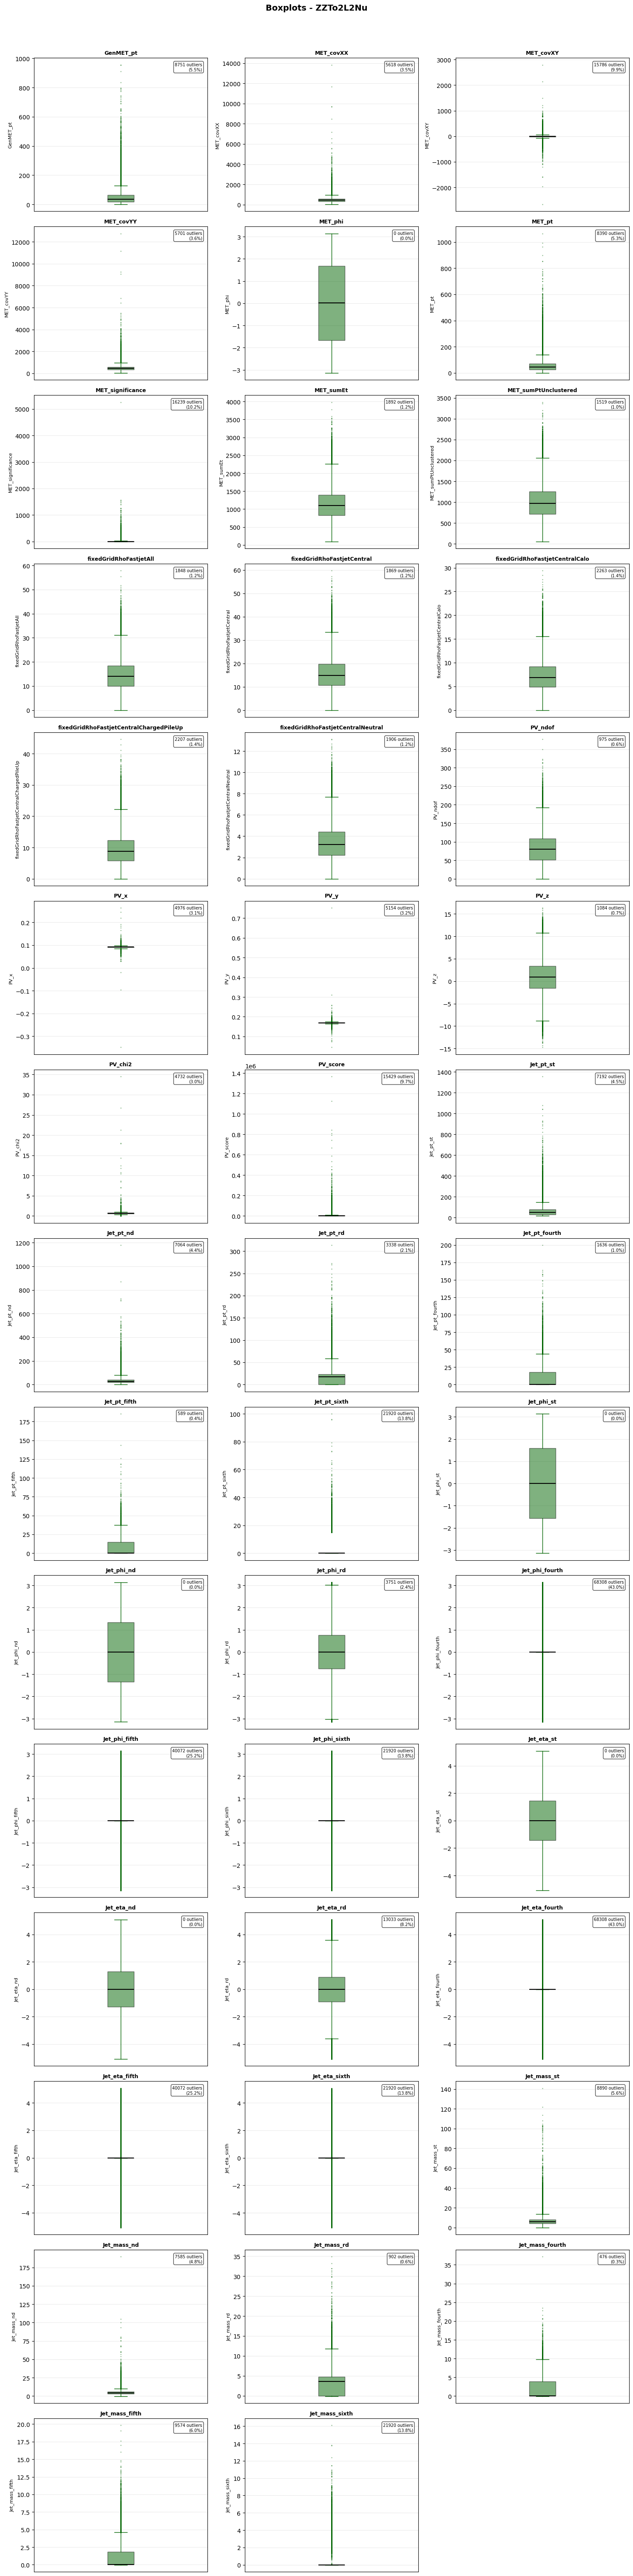

In [28]:
_boxplots(df, float_features, label=label, color=color)

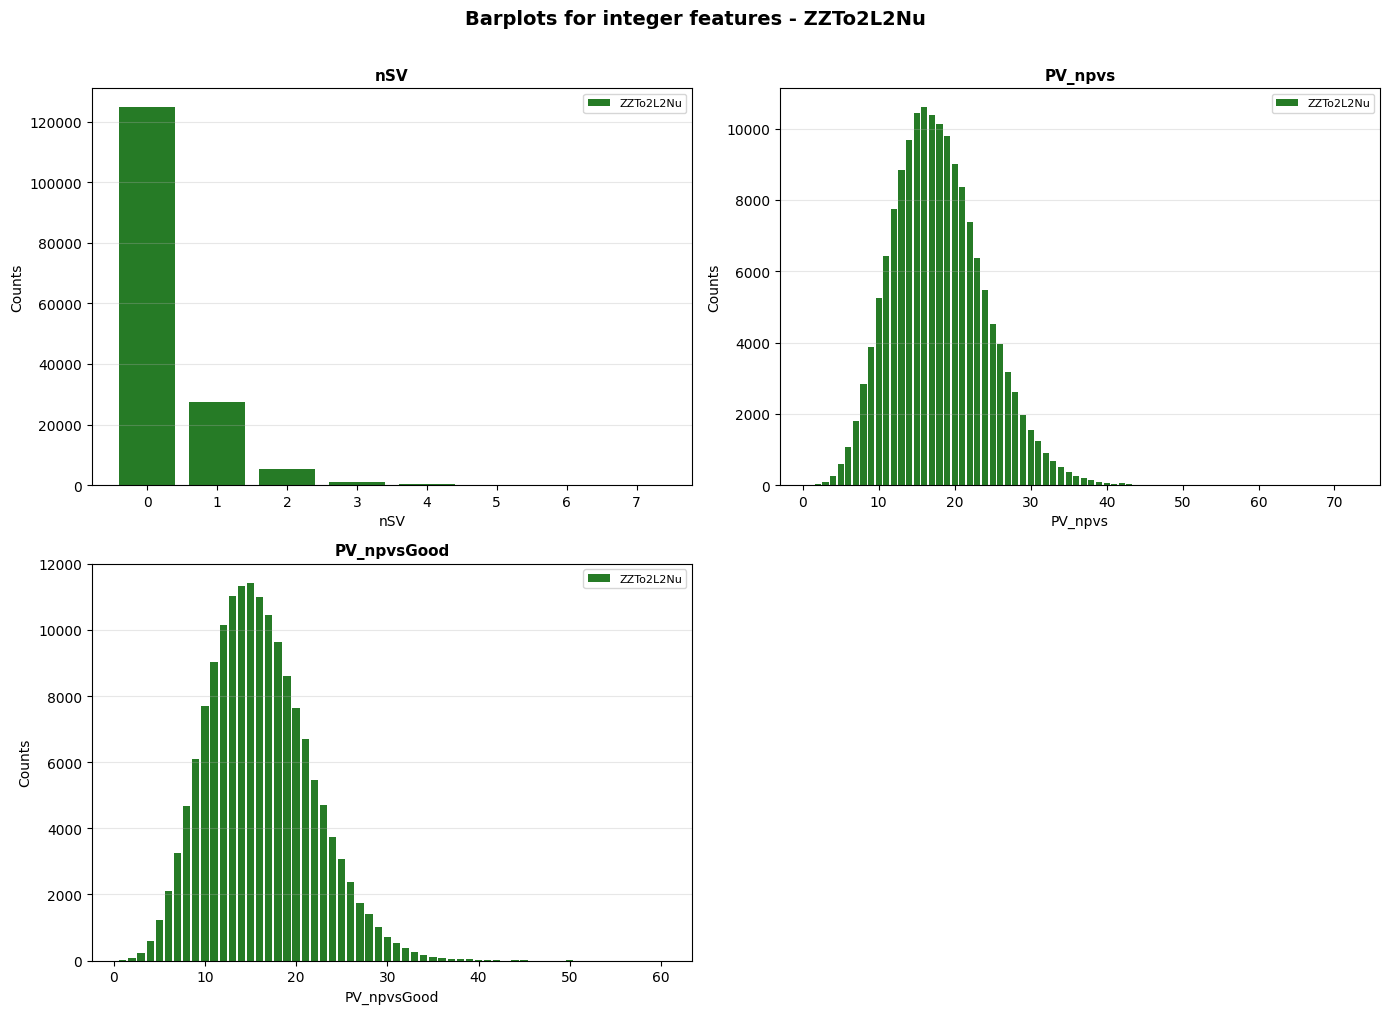

In [29]:
_data_barplots(df, label=label, color=color)